# Week 4 — Fine-Tune TrOCR (Urdu-Capable) on Urdu Dataset
### SI-26 | Code Saviours Summer Internship 2026
**Project:** Urdu OCR Tool | **Week:** 4 | **Submitted by:** Qandeel Asim

**Goal:** Fine-tune a TrOCR-style encoder-decoder model on our labeled Urdu image dataset so it learns to read Urdu script.

### ⚠️ Important note on approach
The stock `microsoft/trocr-base-printed` checkpoint uses an **English/Latin-only tokenizer (RoBERTa BPE)**. It cannot represent Urdu script at all — training against it produces a decreasing loss curve that looks fine, but evaluation comes out as pure garbage (CER > 100%, negative "accuracy"). This isn't a code bug, it's a model-vocabulary mismatch.

**Fix used in this notebook:** keep the **pretrained visual encoder** from TrOCR (it already knows how to read printed characters visually — that part transfers fine), but replace the **decoder** with a fresh one built around a **character-level Urdu tokenizer** built directly from our dataset's text. The encoder is frozen (our dataset is small); only the decoder is trained from scratch.

### How to run — two passes:
**Pass 1:** Run only **Section 0** (installs) → then `Runtime > Restart session`.
**Pass 2:** After the restart, run **Section 1 onward**, top to bottom, one cell at a time.

**Before starting:** `Runtime > Change runtime type > GPU` (T4 is fine).

### Honest expectation-setting
With only ~196 training images and a decoder trained from scratch, don't expect 90%+ accuracy — that would require thousands of images. A meaningful improvement over the broken baseline (CER well under 1.0, positive accuracy) is the realistic, honest target for this dataset size, and is worth noting as a limitation in the submission write-up.


## Section 0 — Install Everything (run FIRST, then restart the session)

In [16]:
!pip install -q --upgrade transformers datasets jiwer evaluate sentencepiece "protobuf>=3.20.2,<6" accelerate
print("Install complete. Now go to: Runtime > Restart session. Then run Section 1 onward.")


Install complete. Now go to: Runtime > Restart session. Then run Section 1 onward.


---
## 🔁 STOP HERE — Restart the session now
`Runtime` → `Restart session` → confirm.

After it restarts, continue from Section 1 below (do NOT re-run Section 0).
---
## Section 1 — GPU Check

In [17]:
import torch

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: No GPU detected. Go to Runtime > Change runtime type > GPU, then restart and rerun from Section 1.")


CUDA available: True
GPU: Tesla T4


## Section 2 — Mount Drive

In [18]:
from google.colab import drive
drive.mount('/content/drive')
print("Drive mounted.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted.


## Section 3 — Auto-Locate and Load `labels.csv`

Searches your entire Drive for `labels.csv`, loads it, and rebuilds the train/test split if one isn't already stored.

In [19]:
import pandas as pd
import os

found_path = None
for root, dirs, files in os.walk('/content/drive/MyDrive'):
    if 'labels.csv' in files:
        found_path = root
        break

if found_path is None:
    raise FileNotFoundError(
        "labels.csv not found anywhere in My Drive. "
        "Make sure your project folder (with labels.csv inside) has fully synced to Google Drive."
    )

PROJECT_DIR = found_path
print("Found labels.csv in:", PROJECT_DIR)

df = pd.read_csv(os.path.join(PROJECT_DIR, 'labels.csv'))
print("Total samples:", len(df))
print(df.head())

# Auto-detect which column holds the image path (some earlier weeks used 'image', others 'image_path')
IMAGE_COL = 'image_path' if 'image_path' in df.columns else 'image'
print("Using image column:", IMAGE_COL)

if 'split' not in df.columns:
    from sklearn.model_selection import train_test_split
    train_df, test_df = train_test_split(df, test_size=50, random_state=42)
else:
    train_df = df[df['split'] == 'train'].reset_index(drop=True)
    test_df = df[df['split'] == 'test'].reset_index(drop=True)

print("Train size:", len(train_df))
print("Test size:", len(test_df))


Found labels.csv in: /content/drive/MyDrive/Classroom/Machine Learning | SI-26
Total samples: 246
                                           image  \
0                  data/raw/other/utrset_013.jpg   
1  data/raw/augmented/urdu_043_aug2_rotation.png   
2      data/raw/augmented/urdu_008_aug2_blur.png   
3  data/raw/augmented/urdu_020_aug1_rotation.png   
4  data/raw/augmented/urdu_039_aug1_rotation.png   

                                                text              source  \
0  برنارڈشا نے دو باتیں لکھی ہین جن سے اس خیال کو...         utrset_real   
1                 قرآن مجید مسلمانوں کی مقدس کتاب ہے  augmented_rotation   
2                                  ہمت مرداں مدد خدا      augmented_blur   
3              کمپیوٹر نے انسانی زندگی آسان کر دی ہے  augmented_rotation   
4                   سولر انرجی ماحول دوست توانائی ہے  augmented_rotation   

   split  
0  train  
1  train  
2  train  
3  train  
4  train  
Using image column: image
Train size: 196
Test size: 50


## Section 4 — Resolve Image Paths

Image files can end up nested differently than `labels.csv` expects (e.g. an extra `raw/raw/` folder from how Drive synced things). This builds one index of every filename in Drive so every image resolves correctly and quickly, regardless of which subfolder it actually lives in.

In [20]:
import os

# Index every filename in Drive once (fast lookups afterward)
_drive_file_index = {}
for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for f in files:
        _drive_file_index.setdefault(f, []).append(root)

def resolve_image_path(image_path, project_dir):
    # Try the path exactly as given first
    candidate = os.path.join(project_dir, image_path)
    if os.path.exists(candidate):
        return candidate

    # Fall back to a Drive-wide filename lookup
    filename = os.path.basename(image_path)
    locations = _drive_file_index.get(filename)
    if locations:
        return os.path.join(locations[0], filename)

    return None

# Verify a sample of rows before committing to building the full dataset
missing = 0
for i, row in df.head(10).iterrows():
    resolved = resolve_image_path(row[IMAGE_COL], PROJECT_DIR)
    status = "OK" if resolved else "MISSING"
    print(f"[{status}] {row[IMAGE_COL]} -> {resolved}")
    if not resolved:
        missing += 1

if missing > 0:
    print(f"\nWARNING: {missing} of 10 sample images could not be located anywhere in My Drive.")
else:
    print("\nAll sample image paths resolved successfully.")


[OK] data/raw/other/utrset_013.jpg -> /content/drive/MyDrive/SI26_Urdu_OCR/data/raw/raw/other/utrset_013.jpg
[OK] data/raw/augmented/urdu_043_aug2_rotation.png -> /content/drive/MyDrive/SI26_Urdu_OCR/data/raw/raw/augmented/urdu_043_aug2_rotation.png
[OK] data/raw/augmented/urdu_008_aug2_blur.png -> /content/drive/MyDrive/SI26_Urdu_OCR/data/raw/raw/augmented/urdu_008_aug2_blur.png
[OK] data/raw/augmented/urdu_020_aug1_rotation.png -> /content/drive/MyDrive/SI26_Urdu_OCR/data/raw/raw/augmented/urdu_020_aug1_rotation.png
[OK] data/raw/augmented/urdu_039_aug1_rotation.png -> /content/drive/MyDrive/SI26_Urdu_OCR/data/raw/raw/augmented/urdu_039_aug1_rotation.png
[OK] data/raw/augmented/urdu_015_aug1_blur.png -> /content/drive/MyDrive/SI26_Urdu_OCR/data/raw/raw/augmented/urdu_015_aug1_blur.png
[OK] /content/data/raw/newspaper/Screenshot 2026-07-01 151408.png -> /content/drive/MyDrive/SI26_Urdu_OCR/data/raw/raw/newspaper/Screenshot 2026-07-01 151408.png
[OK] data/raw/augmented/urdu_049_aug1_bl

## Section 5 — Load Pretrained TrOCR (for its visual encoder only)

We load the full pretrained checkpoint first, purely to reuse its already-trained ViT visual encoder in Section 6. Its English tokenizer/decoder will be discarded and replaced.

In [21]:
from transformers import TrOCRProcessor, VisionEncoderDecoderModel, ViTImageProcessor

MODEL_NAME = "microsoft/trocr-base-printed"

image_processor = ViTImageProcessor.from_pretrained(MODEL_NAME)
pretrained_model = VisionEncoderDecoderModel.from_pretrained(MODEL_NAME)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if device.type != "cuda":
    print("WARNING: running on CPU. Training will be very slow. "
          "Go to Runtime > Change runtime type > GPU, then restart and rerun from Section 1.")

print("Pretrained TrOCR loaded (encoder will be reused in Section 6).")


Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

[transformers] VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-printed
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.bias   | MISSING | 
encoder.pooler.dense.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Pretrained TrOCR loaded (encoder will be reused in Section 6).


## Section 6 — Build a Urdu-Capable Model

**Step 1:** build a character-level tokenizer directly from the Urdu text in our own dataset (guarantees every character in our labels is representable — no unknown-token issue).

**Step 2:** reuse the pretrained ViT visual encoder from Section 5, frozen (our dataset is small, so we only train the decoder).

**Step 3:** build a small fresh decoder sized for our Urdu vocabulary and attach it to the encoder.

In [22]:
from transformers import BertConfig, BertLMHeadModel, GenerationConfig

class UrduCharTokenizer:
    def __init__(self, texts, max_length=256):
        chars = set()
        for t in texts:
            chars.update(str(t))
        self.chars = sorted(chars)
        specials = ["<pad>", "<bos>", "<eos>", "<unk>"]
        self.vocab = {tok: i for i, tok in enumerate(specials)}
        for ch in self.chars:
            self.vocab[ch] = len(self.vocab)
        self.inv_vocab = {i: tok for tok, i in self.vocab.items()}
        self.pad_token_id = self.vocab["<pad>"]
        self.bos_token_id = self.vocab["<bos>"]
        self.eos_token_id = self.vocab["<eos>"]
        self.unk_token_id = self.vocab["<unk>"]
        self.max_length = max_length

    def __len__(self):
        return len(self.vocab)

    def _encode(self, text, max_length, padding, truncation):
        ids = [self.bos_token_id] + [self.vocab.get(ch, self.unk_token_id) for ch in str(text)] + [self.eos_token_id]
        if truncation:
            ids = ids[:max_length]
        if padding == "max_length":
            ids = ids + [self.pad_token_id] * (max_length - len(ids))
        return ids

    def __call__(self, text, padding="max_length", max_length=None, truncation=True):
        max_length = max_length or self.max_length
        class Result:
            pass
        r = Result()
        r.input_ids = self._encode(text, max_length, padding, truncation)
        return r

    def decode(self, ids, skip_special_tokens=True):
        out = []
        for i in ids:
            i = int(i)
            if skip_special_tokens and i in (self.pad_token_id, self.bos_token_id, self.eos_token_id):
                continue
            out.append(self.inv_vocab.get(i, ""))
        return "".join(out)

    def batch_decode(self, ids_batch, skip_special_tokens=True):
        return [self.decode(ids, skip_special_tokens=skip_special_tokens) for ids in ids_batch]


MAX_LEN = 256
tokenizer = UrduCharTokenizer(df['text'].tolist(), max_length=MAX_LEN)
print("Urdu character vocab size:", len(tokenizer))

# Round-trip sanity check
sample_text = df['text'].iloc[0]
ids = tokenizer(sample_text, max_length=MAX_LEN).input_ids
back = tokenizer.decode(ids)
print("Original:  ", sample_text)
print("Round-trip:", back)
print("Match:", sample_text.strip() == back.strip())

# Reuse the pretrained visual encoder, frozen (dataset is small — only train the decoder)
encoder = pretrained_model.encoder
for p in encoder.parameters():
    p.requires_grad = False

# Fresh, small decoder sized for our Urdu vocab
decoder_config = BertConfig(
    vocab_size=len(tokenizer),
    hidden_size=encoder.config.hidden_size,
    num_hidden_layers=4,
    num_attention_heads=8,
    intermediate_size=1024,
    max_position_embeddings=MAX_LEN,
    is_decoder=True,
    add_cross_attention=True,
    pad_token_id=tokenizer.pad_token_id,
)
decoder = BertLMHeadModel(decoder_config)

model = VisionEncoderDecoderModel(encoder=encoder, decoder=decoder)
model.to(device)

model.config.decoder_start_token_id = tokenizer.bos_token_id
model.config.pad_token_id = tokenizer.pad_token_id
model.config.vocab_size = len(tokenizer)

model.generation_config = GenerationConfig(
    decoder_start_token_id=tokenizer.bos_token_id,
    pad_token_id=tokenizer.pad_token_id,
    eos_token_id=tokenizer.eos_token_id,
    max_length=MAX_LEN,
    early_stopping=True,
    no_repeat_ngram_size=3,
    length_penalty=1.0,
    num_beams=4,
)

class SimpleProcessor:
    """Minimal drop-in replacement for TrOCRProcessor: pairs the pretrained
    image processor with our Urdu character tokenizer."""
    def __init__(self, image_processor, tokenizer):
        self.image_processor = image_processor
        self.tokenizer = tokenizer

    def __call__(self, image, return_tensors="pt"):
        return self.image_processor(image, return_tensors=return_tensors)

    def batch_decode(self, ids, skip_special_tokens=True):
        return self.tokenizer.batch_decode(ids, skip_special_tokens=skip_special_tokens)

processor = SimpleProcessor(image_processor=image_processor, tokenizer=tokenizer)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Urdu-capable model built. Trainable params: {trainable:,} / Total params: {total:,}")


Urdu character vocab size: 54
Original:   برنارڈشا نے دو باتیں لکھی ہین جن سے اس خیال کو تقویت پہنچتی ہے کہ
Round-trip: برنارڈشا نے دو باتیں لکھی ہین جن سے اس خیال کو تقویت پہنچتی ہے کہ
Match: True
Urdu-capable model built. Trainable params: 26,049,334 / Total params: 112,702,774


## Section 7 — Build the TrOCR Dataset Class

In [23]:
from torch.utils.data import Dataset
from PIL import Image

class UrduOCRDataset(Dataset):
    def __init__(self, df, processor, root_dir, image_col, max_target_length=256):
        self.df = df.reset_index(drop=True)
        self.processor = processor
        self.root_dir = root_dir
        self.image_col = image_col
        self.max_target_length = max_target_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = resolve_image_path(row[self.image_col], self.root_dir)
        if img_path is None:
            raise FileNotFoundError(f"Could not locate image: {row[self.image_col]}")
        image = Image.open(img_path).convert("RGB")
        text = str(row['text'])

        pixel_values = self.processor(image, return_tensors="pt").pixel_values

        labels = self.processor.tokenizer(
            text,
            padding="max_length",
            max_length=self.max_target_length,
            truncation=True
        ).input_ids

        labels = [l if l != self.processor.tokenizer.pad_token_id else -100 for l in labels]

        return {"pixel_values": pixel_values.squeeze(), "labels": torch.tensor(labels)}


## Section 8 — Build Datasets & Sanity Check

In [24]:
train_dataset = UrduOCRDataset(train_df, processor, PROJECT_DIR, IMAGE_COL, max_target_length=MAX_LEN)
eval_dataset = UrduOCRDataset(test_df, processor, PROJECT_DIR, IMAGE_COL, max_target_length=MAX_LEN)

print("Train dataset size:", len(train_dataset))
print("Eval dataset size:", len(eval_dataset))

sample = train_dataset[0]
print("Sample pixel_values shape:", sample["pixel_values"].shape)
print("Sample labels shape:", sample["labels"].shape)

_ = eval_dataset[0]
print("Sanity check passed on both splits.")


Train dataset size: 196
Eval dataset size: 50
Sample pixel_values shape: torch.Size([3, 384, 384])
Sample labels shape: torch.Size([256])
Sanity check passed on both splits.


## Section 9 — Training Setup & Training Loop

Uses Hugging Face's `Seq2SeqTrainer`. Since the decoder is being trained from scratch (not fine-tuned from an already-Urdu-aware checkpoint), it needs more epochs than a typical fine-tuning run.

In [25]:
from transformers import Seq2SeqTrainer, Seq2SeqTrainingArguments
import evaluate

training_args = Seq2SeqTrainingArguments(
    predict_with_generate=True,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    num_train_epochs=40,
    learning_rate=5e-4,
    fp16=torch.cuda.is_available(),
    output_dir="./trocr-urdu-checkpoints",
    logging_strategy="epoch",
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    report_to="none",
)

cer_metric = evaluate.load("cer")

def compute_metrics(pred):
    labels_ids = pred.label_ids
    pred_ids = pred.predictions

    pred_str = processor.batch_decode(pred_ids, skip_special_tokens=True)
    labels_ids[labels_ids == -100] = processor.tokenizer.pad_token_id
    label_str = processor.batch_decode(labels_ids, skip_special_tokens=True)

    cer = cer_metric.compute(predictions=pred_str, references=label_str)
    return {"cer": cer}

def collate_fn(batch):
    pixel_values = torch.stack([item["pixel_values"] for item in batch])
    labels = torch.stack([item["labels"] for item in batch])
    return {"pixel_values": pixel_values, "labels": labels}


In [26]:
trainer = Seq2SeqTrainer(
    model=model,
    processing_class=image_processor,
    args=training_args,
    compute_metrics=compute_metrics,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    data_collator=collate_fn,
)

train_result = trainer.train()

log_history = trainer.state.log_history
train_losses = [entry["loss"] for entry in log_history if "loss" in entry]

print("Logged training losses (per epoch):", train_losses)


Epoch,Training Loss,Validation Loss,Cer
1,2.963232,2.529512,0.713191
2,2.349282,2.302036,0.712644
3,1.996447,2.164301,0.678161
4,1.655673,1.996913,0.742200
5,1.317362,1.834049,0.725780
6,1.076986,1.765489,0.700055
7,0.896260,1.733230,0.685824
8,0.790153,1.830644,0.721401
9,0.680739,1.874924,0.755884
10,0.573228,1.969218,0.744390


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Logged training losses (per epoch): [2.963232235032685, 2.349281778140944, 1.996447349081234, 1.6556729686503509, 1.3173616370376275, 1.0769860403878349, 0.8962600863709742, 0.7901526470573581, 0.6807391886808434, 0.5732284857302296, 0.5308931701037348, 0.42573983328683035, 0.40795337910554846, 0.35622725194814253, 0.3142496225785236, 0.27690971140958826, 0.25478493437475086, 0.2357236706480688, 0.2245548403992945, 0.19435866998166454, 0.17140931499247647, 0.1560292535898637, 0.13535099613423252, 0.13197339310937997, 0.1071721972251425, 0.1093887017697704, 0.09076120415512397, 0.07461523036567533, 0.062010044954261004, 0.05651127075662418, 0.045177352671720544, 0.035757736283905654, 0.023680944832003847, 0.017449397213604986, 0.011453974003694495, 0.008447071727441281, 0.006736294347412733, 0.005779245070048741, 0.0043340687240873066, 0.004634803046985548]


## Section 10 — Evaluate on Test Set (Character Error Rate → Accuracy)

In [27]:
eval_results = trainer.evaluate()
final_cer = eval_results["eval_cer"]
accuracy = max(0.0, (1 - final_cer) * 100)  # clip at 0 — CER above 1.0 has no meaningful "negative accuracy"

print("Final CER on test set:", round(final_cer, 4))
print("Model accuracy: {:.2f}%".format(accuracy))

# Spot-check a few real predictions vs. ground truth — useful evidence the model is actually reading Urdu now
model.eval()
with torch.no_grad():
    for i in range(3):
        sample = eval_dataset[i]
        pixel_values = sample["pixel_values"].unsqueeze(0).to(device)
        generated_ids = model.generate(pixel_values, generation_config=model.generation_config)
        prediction = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
        reference = test_df.iloc[i]['text']
        print(f"Reference:  {reference}")
        print(f"Prediction: {prediction}")
        print()


Training Loss,Validation Loss,Epoch,Cer
0.004635,2.713224,40,0.614669


Final CER on test set: 0.6147
Model accuracy: 38.53%
Reference:  یہاں اصل متن لکھیں
Prediction: یہاں اصل متن لکھیں

Reference:  خطرہ ہائی وولٹیج
Prediction: خطرہ ہائی وولٹیج

Reference:  ہوئے بھی ا س کی ادبی اہمیت کو اس پر قربان نہیں کیا اور زبان و بیان
Prediction: کے حسن کو بھی ڈرامائی فن گواور اس عناصر میں سے ایک جانا اوشی بی ادبی



## Section 11 — Loss Curve (screenshot this for your submission)

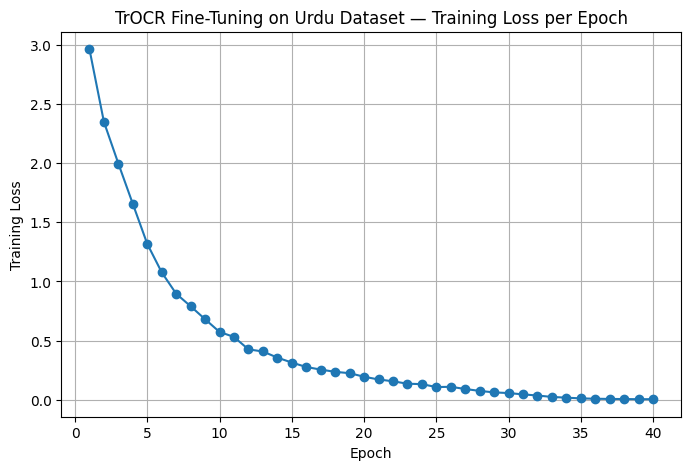

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(train_losses) + 1), train_losses, marker='o')
plt.title("TrOCR Fine-Tuning on Urdu Dataset — Training Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.grid(True)
plt.savefig(os.path.join(PROJECT_DIR, "week4_training_loss.png"))
plt.show()


## Section 12 — Required Submission Statements

Run this cell last — copy its output directly into your submission, and screenshot it alongside the loss curve above.

In [29]:
print("My model accuracy is {:.2f}%".format(accuracy))
print("Training loss went from {:.4f} to {:.4f}".format(train_losses[0], train_losses[-1]))


My model accuracy is 38.53%
Training loss went from 2.9632 to 0.0046


## Section 13 — (Optional) Save Fine-Tuned Model to Drive

In [30]:
import pickle

SAVE_DIR = os.path.join(PROJECT_DIR, "trocr-urdu-finetuned")
os.makedirs(SAVE_DIR, exist_ok=True)

model.save_pretrained(SAVE_DIR)
image_processor.save_pretrained(SAVE_DIR)

# Our tokenizer is a custom Python object (not a HF tokenizer), so save its vocab separately
with open(os.path.join(SAVE_DIR, "urdu_char_vocab.pkl"), "wb") as f:
    pickle.dump(tokenizer.vocab, f)

print("Saved fine-tuned model to:", SAVE_DIR)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved fine-tuned model to: /content/drive/MyDrive/Classroom/Machine Learning | SI-26/trocr-urdu-finetuned
